In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import plotly.express as px
import sqlite3
import os
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
conn = sqlite3.connect("test_players.sqlite")
df = pd.read_sql("SELECT * FROM player_features", conn)
print(df.shape)
df

(9684, 16)


,username,n_games,avg_rating,avg_capture_rate,avg_check_rate,avg_moves_per_game,avg_pawn_push_phase,pct_games_never_pushed_contested_pawn,avg_castle_phase,pct_games_never_castled,avg_queen_dev_phase,pct_games_queen_never_moved,avg_minor_dev_phase,avg_minor_pieces_developed,opening_diversity,n_distinct_openings
0,DailyTornado,60,2676.000000,0.211733,0.051730,44.350000,0.232028,0.050000,0.259508,0.100000,0.351004,0.033333,0.189130,3.983333,0.533333,32
1,Kysylyn,60,2572.833333,0.215810,0.070587,38.100000,0.293440,0.066667,0.317663,0.133333,0.400484,0.066667,0.214391,3.900000,0.516667,31
2,Horticulture_Johnson,60,1103.233333,0.263296,0.066435,25.233333,0.369800,0.266667,0.382183,0.216667,0.522004,0.266667,0.257733,3.550000,0.466667,28
3,sjh918092,60,1186.283333,0.283687,0.077179,20.116667,0.486133,0.283333,0.380393,0.333333,0.545577,0.200000,0.312264,3.183333,0.366667,22
4,lkjh-098_7,57,1472.052632,0.209560,0.060282,43.157895,0.471084,0.315789,0.375796,0.192982,0.260649,0.070175,0.200978,3.596491,0.230769,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9679,Pacojonex,60,1558.916667,0.259939,0.065307,32.466667,0.320600,0.066667,0.355732,0.300000,0.407546,0.050000,0.265159,3.666667,0.400000,24
9680,serge2000,60,1380.133333,0.261125,0.121413,26.766667,0.411535,0.300000,0.344318,0.183333,0.478810,0.133333,0.265521,3.766667,0.500000,30
9681,Bianca0910,60,2210.933333,0.221082,0.064876,35.766667,0.309750,0.116667,0.271032,0.100000,0.396929,0.116667,0.224759,3.883333,0.716667,43
9682,Safocl53,60,1117.700000,0.242802,0.121382,24.866667,0.402492,0.350000,0.461296,0.583333,0.292802,0.083333,0.368684,3.266667,0.300000,18


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9684 entries, 0 to 9683
Data columns (total 16 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   username                               9684 non-null   object 
 1   n_games                                9684 non-null   int64  
 2   avg_rating                             9684 non-null   float64
 3   avg_capture_rate                       9684 non-null   float64
 4   avg_check_rate                         9684 non-null   float64
 5   avg_moves_per_game                     9684 non-null   float64
 6   avg_pawn_push_phase                    9684 non-null   float64
 7   pct_games_never_pushed_contested_pawn  9684 non-null   float64
 8   avg_castle_phase                       9653 non-null   float64
 9   pct_games_never_castled                9684 non-null   float64
 10  avg_queen_dev_phase                    9684 non-null   float64
 11  pct_

In [4]:
df.describe()

,n_games,avg_rating,avg_capture_rate,avg_check_rate,avg_moves_per_game,avg_pawn_push_phase,pct_games_never_pushed_contested_pawn,avg_castle_phase,pct_games_never_castled,avg_queen_dev_phase,pct_games_queen_never_moved,avg_minor_dev_phase,avg_minor_pieces_developed,opening_diversity,n_distinct_openings
count,9684.000000,9684.000000,9684.000000,9684.000000,9684.000000,9684.000000,9684.000000,9653.000000,9684.000000,9684.000000,9684.000000,9684.000000,9684.000000,9684.000000,9684.000000
mean,58.746386,1472.501874,0.239096,0.076445,32.247701,0.343333,0.201846,0.360255,0.279703,0.388940,0.113470,0.259756,3.697103,0.405641,23.590562
std,5.428810,347.858718,0.019945,0.021931,5.311086,0.066455,0.102155,0.078022,0.190598,0.073603,0.069257,0.049987,0.248021,0.117644,6.756850
min,20.000000,415.883333,0.073790,0.010878,9.447368,0.092106,0.000000,0.096000,0.000000,0.069987,0.000000,0.140693,1.500000,0.033333,2.000000
25%,60.000000,1223.215678,0.226200,0.061463,28.700000,0.298192,0.133333,0.307107,0.150000,0.347512,0.066667,0.225305,3.616667,0.333333,19.000000
50%,60.000000,1480.075000,0.238633,0.073481,32.216667,0.337697,0.183333,0.353971,0.233333,0.393461,0.100000,0.252774,3.766667,0.416667,24.000000
75%,60.000000,1726.637500,0.251579,0.088408,35.766667,0.382964,0.266667,0.405096,0.350000,0.437262,0.150000,0.286419,3.850000,0.483333,28.000000
max,60.000000,2676.000000,0.346043,0.218879,55.868421,0.682379,0.892857,0.957447,1.000000,0.687071,0.666667,0.546821,4.000000,0.909091,49.000000


In [5]:
# Checking missing values
df.isna().sum()

username                                  0
n_games                                   0
avg_rating                                0
avg_capture_rate                          0
avg_check_rate                            0
avg_moves_per_game                        0
avg_pawn_push_phase                       0
pct_games_never_pushed_contested_pawn     0
avg_castle_phase                         31
pct_games_never_castled                   0
avg_queen_dev_phase                       0
pct_games_queen_never_moved               0
avg_minor_dev_phase                       0
avg_minor_pieces_developed                0
opening_diversity                         0
n_distinct_openings                       0
dtype: int64

In [6]:
# Dropping missing values
df = df.dropna()
# Checking missing values after dropping missing values
df.isna().sum()

username                                 0
n_games                                  0
avg_rating                               0
avg_capture_rate                         0
avg_check_rate                           0
avg_moves_per_game                       0
avg_pawn_push_phase                      0
pct_games_never_pushed_contested_pawn    0
avg_castle_phase                         0
pct_games_never_castled                  0
avg_queen_dev_phase                      0
pct_games_queen_never_moved              0
avg_minor_dev_phase                      0
avg_minor_pieces_developed               0
opening_diversity                        0
n_distinct_openings                      0
dtype: int64

Generating Distribution Plot for n_games...


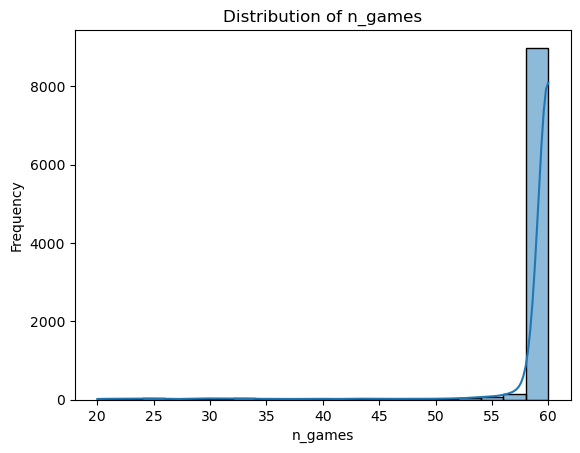

Generating Distribution Plot for avg_rating...


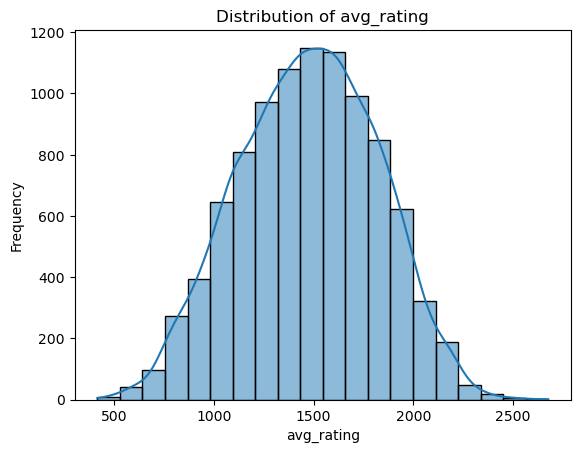

Generating Distribution Plot for avg_capture_rate...


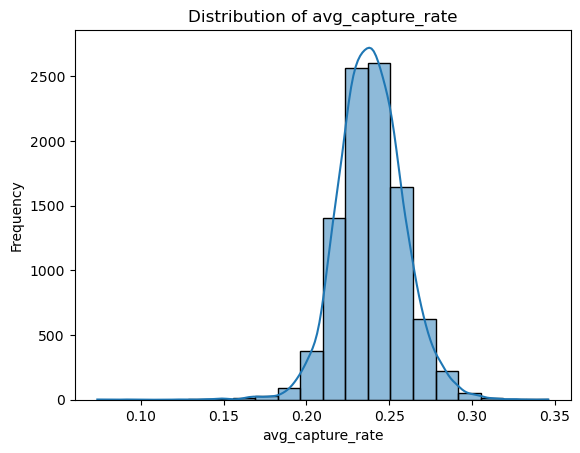

Generating Distribution Plot for avg_check_rate...


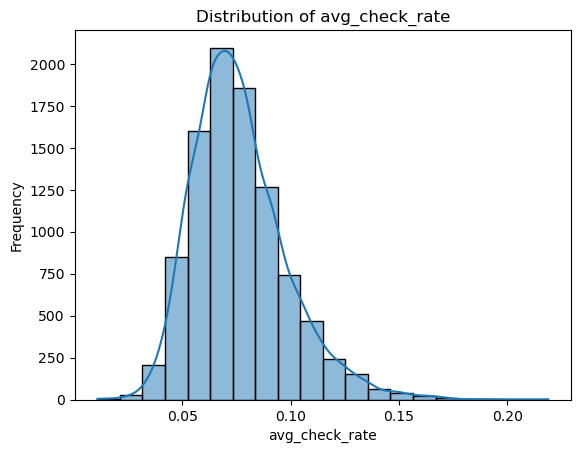

Generating Distribution Plot for avg_moves_per_game...


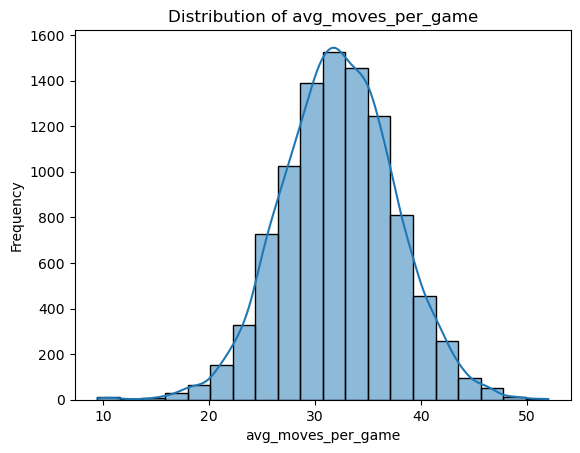

Generating Distribution Plot for avg_pawn_push_phase...


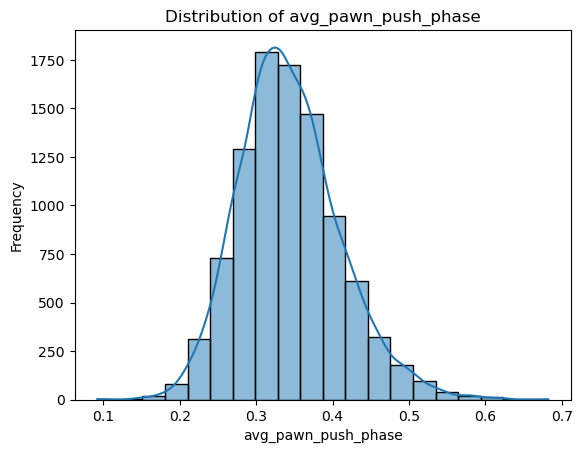

Generating Distribution Plot for pct_games_never_pushed_contested_pawn...


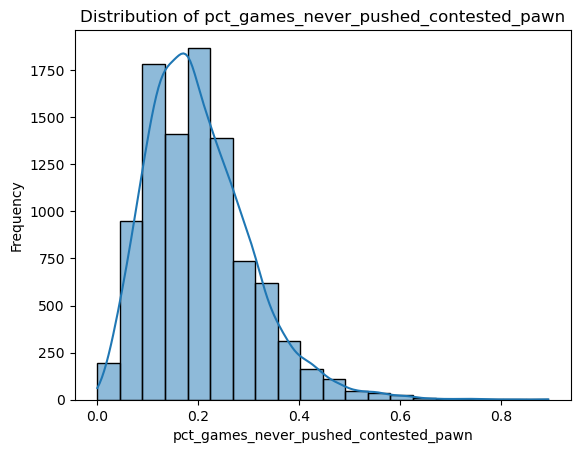

Generating Distribution Plot for avg_castle_phase...


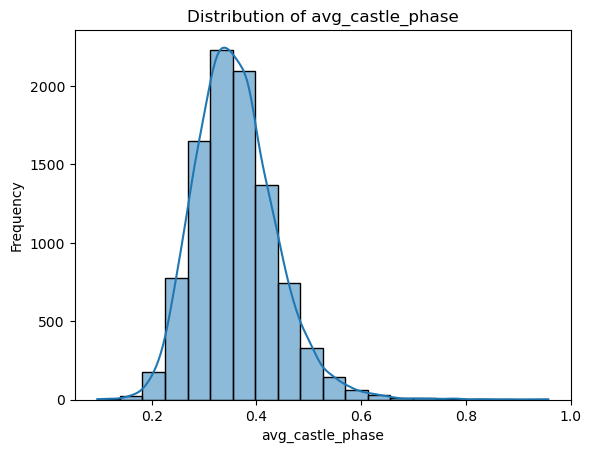

Generating Distribution Plot for pct_games_never_castled...


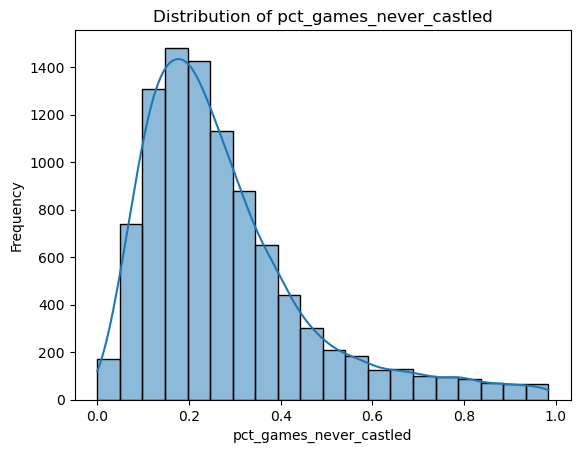

Generating Distribution Plot for avg_queen_dev_phase...


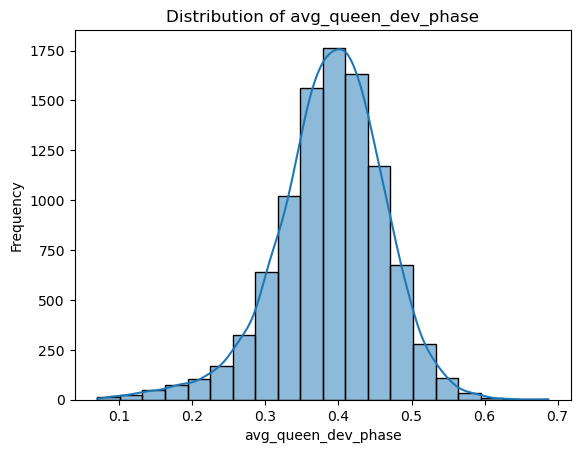

Generating Distribution Plot for pct_games_queen_never_moved...


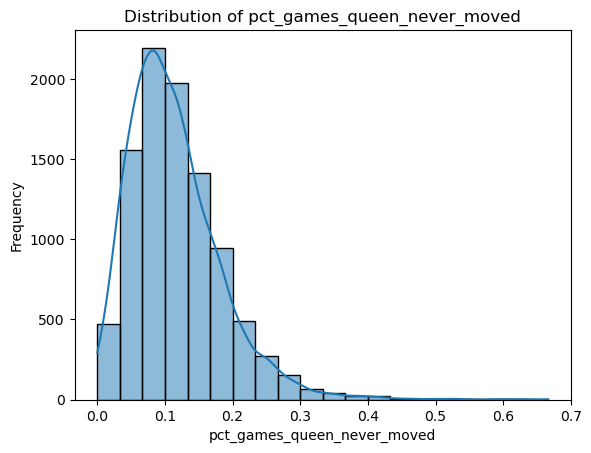

Generating Distribution Plot for avg_minor_dev_phase...


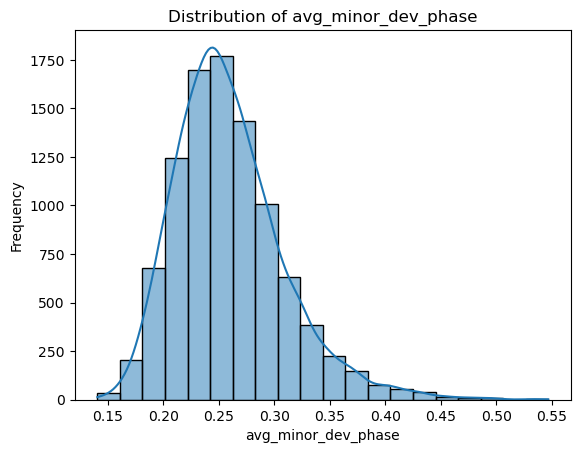

Generating Distribution Plot for avg_minor_pieces_developed...


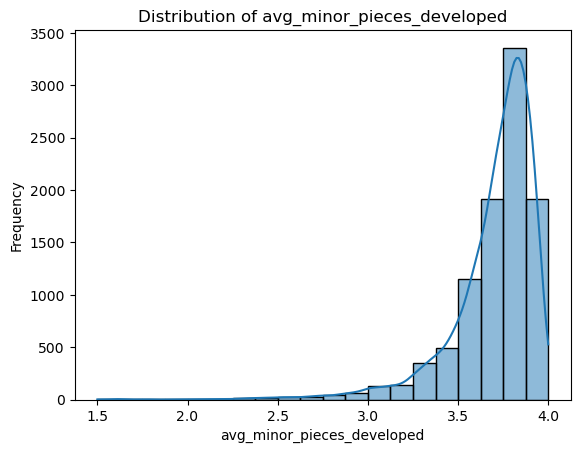

Generating Distribution Plot for opening_diversity...


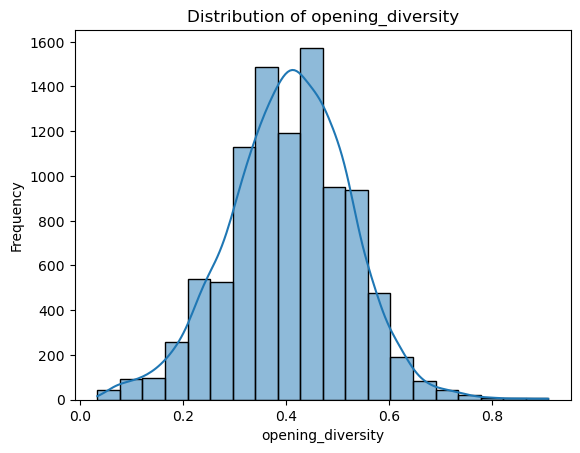

Generating Distribution Plot for n_distinct_openings...


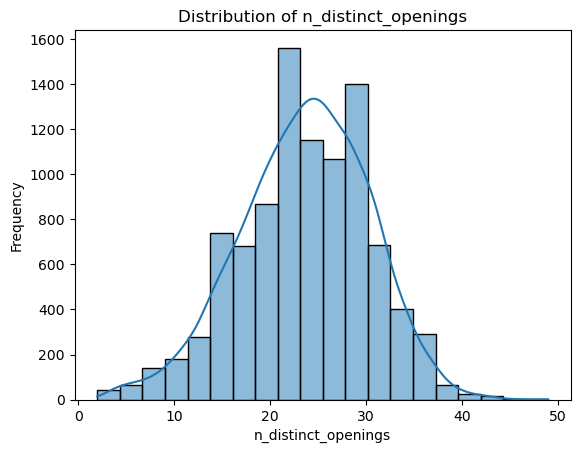

In [7]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

if len(numerical_columns) > 0:
    for col in numerical_columns:
        try:
            print(f"Generating Distribution Plot for {col}...")
            plt.figure()
            sns.histplot(
                data=df,
                x=col,
                kde=True,
                bins=20
            )
            plt.title(f'Distribution of {col}')
            plt.xlabel(col)
            plt.ylabel("Frequency")
            plt.show()
        except Exception as e:
            print(f"Distribution Plot Error for {col}: {e}")

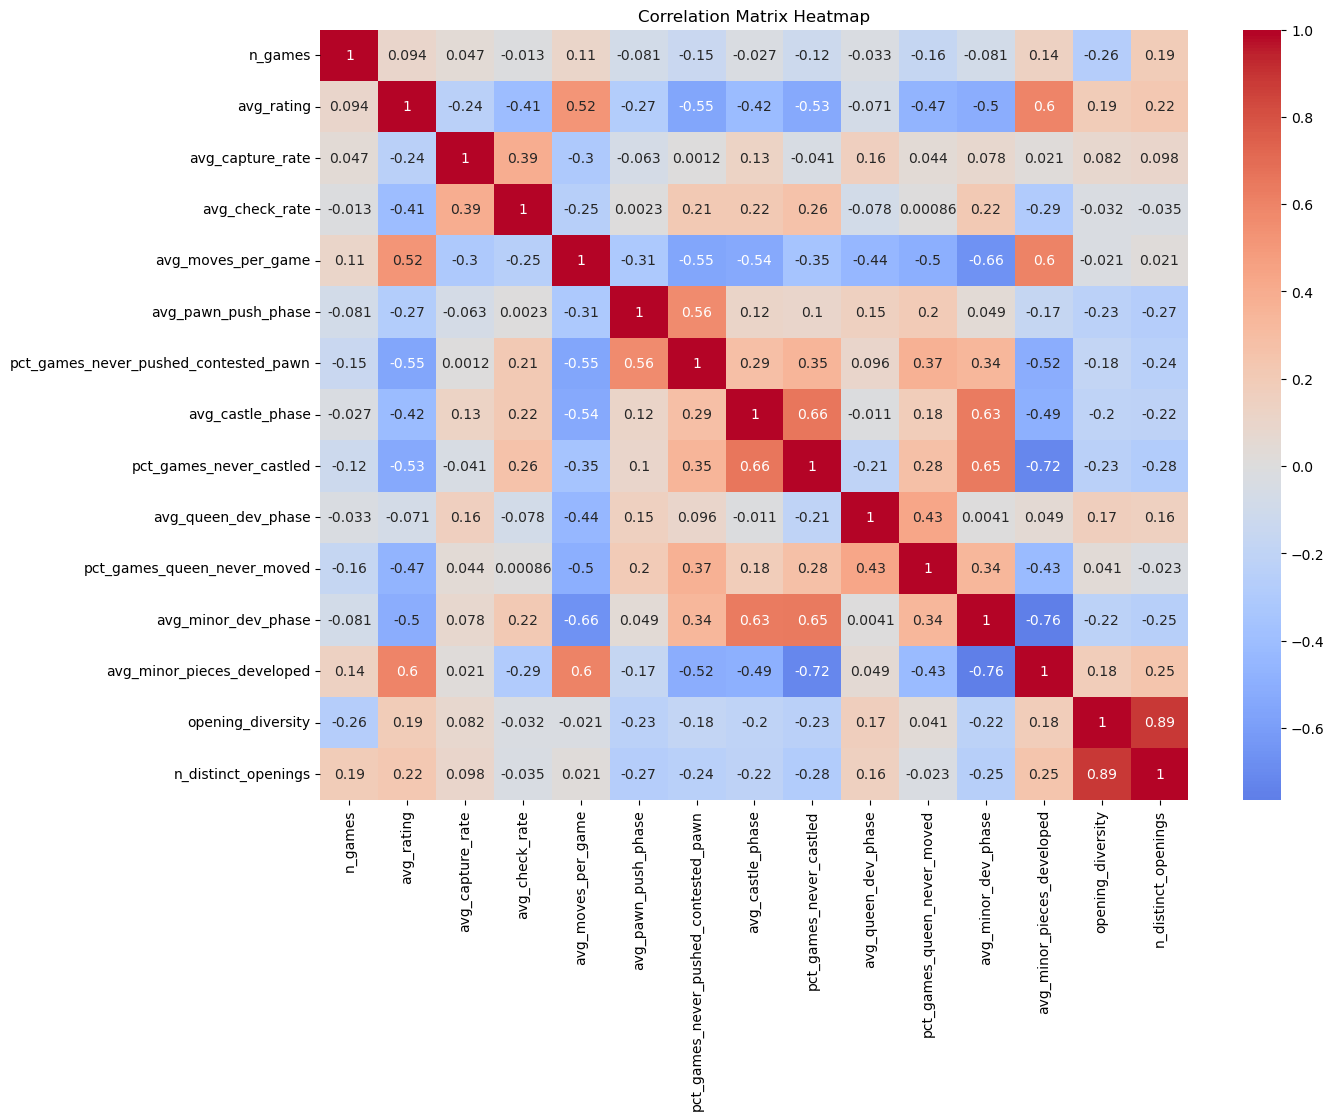

In [8]:
# Compute correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Create heatmap to visualize correlations
plt.figure(figsize=(14,10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix Heatmap")
plt.show()

In [9]:
# From the above mean and standard deviation we see that the data needs scaling
numeric_features = df.drop(columns=["n_games", "n_distinct_openings", "username", "avg_rating", "avg_pawn_push_phase", "opening_diversity", "avg_moves_per_game", "avg_queen_dev_phase", "avg_check_rate", "avg_capture_rate"], axis=1)
scaler = StandardScaler()
processed_data = scaler.fit_transform(numeric_features)

# Instantiating the variables
n_clusters = range(2, 11)
inertia_errors = []
silhouette_scores = []

# Add `for` loop to train model and calculate inertia.
for k in n_clusters:
    model= KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(processed_data)
    inertia_errors.append(model.inertia_)

C:\Users\user\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\user\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\user\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\user\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^

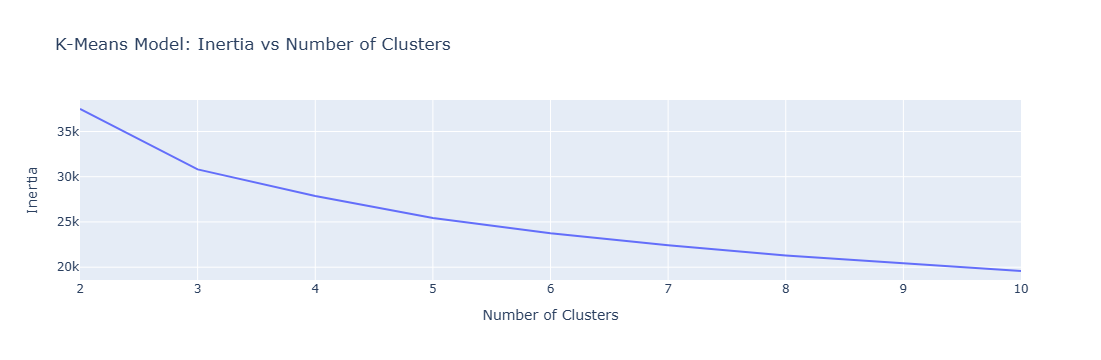

In [10]:
# Create line plot of `inertia_errors` vs `n_clusters`
fig = px.line(x=n_clusters, y=inertia_errors, title="K-Means Model: Inertia vs Number of Clusters")
fig.update_layout(xaxis_title="Number of Clusters", yaxis_title="Inertia")
fig.show()

In [11]:
# Checking silhouette score for deciding on k value
silhouette_scores = []

for k in n_clusters:
    # Create and fit KMeans model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(processed_data)

    # Calculate silhouette score
    silhouette_avg = silhouette_score(processed_data, cluster_labels)
    silhouette_scores.append(silhouette_avg)

    print(f"k={k}: Silhouette Score = {silhouette_avg:.4f}")

k=2: Silhouette Score = 0.3715
k=3: Silhouette Score = 0.2562
k=4: Silhouette Score = 0.2276
k=5: Silhouette Score = 0.1866
k=6: Silhouette Score = 0.1855
k=7: Silhouette Score = 0.1667
k=8: Silhouette Score = 0.1697
k=9: Silhouette Score = 0.1699
k=10: Silhouette Score = 0.1578


In [12]:
# Build our Final model
# Chosen Clusters 'k' = 2
final_model = KMeans(n_clusters=2, random_state=42, n_init=10)

# Fit model to data
final_model.fit(processed_data)

KMeans(n_clusters=2, n_init=10, random_state=42)

In [13]:
# Fitting the data points into Clusters for both the original and numeric only data
labels = (final_model.labels_)
df['clusters'] = labels
numeric_features['clusters'] = labels
numeric_features.head()

C:\Users\user\AppData\Local\Temp\ipykernel_3776\658771458.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,pct_games_never_pushed_contested_pawn,avg_castle_phase,pct_games_never_castled,pct_games_queen_never_moved,avg_minor_dev_phase,avg_minor_pieces_developed,clusters
0,0.050000,0.259508,0.100000,0.033333,0.189130,3.983333,1
1,0.066667,0.317663,0.133333,0.066667,0.214391,3.900000,1
2,0.266667,0.382183,0.216667,0.266667,0.257733,3.550000,0
3,0.283333,0.380393,0.333333,0.200000,0.312264,3.183333,0
4,0.315789,0.375796,0.192982,0.070175,0.200978,3.596491,1


In [14]:
inspection = numeric_features.groupby('clusters').mean()
inspection.T

clusters,0,1
pct_games_never_pushed_contested_pawn,0.277020,0.171115
avg_castle_phase,0.432160,0.331097
pct_games_never_castled,0.475777,0.196944
pct_games_queen_never_moved,0.157909,0.095105
avg_minor_dev_phase,0.312449,0.237887
avg_minor_pieces_developed,3.440051,3.804344


In [15]:
# plotting a group plot to understand meaning of each cluster
inspection_display = inspection.copy()
inspection_display["avg_minor_pieces_developed"] = inspection_display["avg_minor_pieces_developed"] / 4

fig = px.bar(
    inspection_display,
    barmode="group",
    title="Mean player behvaiour by Cluster"
)
fig.update_layout(xaxis_title="Clusters", yaxis_title="Count")
fig.show()

In [16]:
# Fit K-Means on all scaled features, then overlay onto the PCA dataframe and visualize the clusters
transformer = PCA(n_components=2, random_state=42)
X = transformer.fit_transform(processed_data)
X_pca = pd.DataFrame(X, columns=["PC1", "PC2"])
X_pca["labels"] = final_model.labels_.astype(str)

fig = px.scatter(
    X_pca, x="PC1", y="PC2", color="labels",
    title="Player Style Clusters (PCA projection)"
)
fig.show()

In [17]:
cluster_div = X_pca["labels"].value_counts()

fig = px.bar( 
        data_frame=cluster_div,
        orientation="h",
        title="Cluster Distribution"
    )

fig.show()

## Feature Engineering

### Initial candidate features

Before settling on a final feature set, a broader range of behavioral signals was extracted and tested, covering both piece-development timing and general playing tendencies:

- `avg_rating` — the player's average rating across their pulled games
- `avg_capture_rate` — fraction of the player's own moves that were captures
- `avg_check_rate` — fraction of the player's own moves that delivered check
- `avg_moves_per_game` — average number of moves the player made per game
- `avg_pawn_push_phase` — game-phase of the player's first pawn advance into contested territory
- `avg_queen_dev_phase` — game-phase of the first time the player's queen left its starting square
- `pct_games_never_pushed_contested_pawn`
- `pct_games_never_castled`
- `pct_games_queen_never_moved`
- `avg_castle_phase`
- `avg_minor_dev_phase`
- `avg_minor_pieces_developed`
- `opening_diversity`(ratio) & `n_distinct_openings`(the raw count) — of distinct ECO codes to total games played

`avg_rating` was excluded from clustering by design — its scale (hundreds/thousands) dominated distance calculations when included, and the goal of this project was to find genuine stylistic variation independent of skill level, not to re-derive rating.

`avg_capture_rate`, `avg_check_rate`, `avg_moves_per_game`, `avg_pawn_push_phase`, `avg_queen_dev_phase`, and `opening_diversity` were tested but ultimately dropped: their means were nearly identical across candidate clusters, indicating they added noise to the distance calculation rather than separating signal. Removing them roughly doubled the silhouette score, confirming they were diluting rather than contributing to cluster quality.

---

## Final Feature Set

The final model uses six features, all centered on one underlying theme: **how quickly and completely a player establishes king safety and piece development.**

#### `pct_games_never_pushed_contested_pawn`
**What it measures:** How often a player never advances a pawn into contested central territory (past the board's midline) during a game.
**How it is calculated:** For each game, checked whether any pawn move by the player crossed into the contested zone (rank 5+ for White, rank 4- for Black). Games where this never occurred are counted; the count is divided by total games to get a percentage.
**Interpretation:** Higher values indicate a more conservative, restrained approach to central pawn play.

#### `avg_castle_phase`
**What it measures:** How early or late a player castles relative to the length of the game.
**How it is calculated:** For games where the player castles, the castling move is converted into a fraction of the game's total length. These values are then averaged across the player's games.
**Interpretation:** Lower values indicate earlier castling; higher values indicate later castling.

#### `pct_games_never_castled`
**What it measures:** How often a player never castles at all during a game.
**How it is calculated:** Fraction of the player's games in which no castling move (kingside or queenside) ever occurs. Computed separately from `avg_castle_phase` since a "never castled" game has no phase value to average.
**Interpretation:** Higher values indicate a player who frequently leaves their king uncastled for the entire game — either a deliberate stylistic pattern or a risk factor.

#### `pct_games_queen_never_moved`
**What it measures:** How often a player's queen never leaves its starting square during a game.
**How it is calculated:** Fraction of games in which the queen remains on its starting square (d1/d8) for the player's entire set of moves.
**Interpretation:** Higher values indicate a player who keeps the queen passive or undeveloped, whether by style or because the game ended before development became relevant.
#### `avg_minor_dev_phase`
**What it measures:** How early, on average, a player develops their minor pieces (bishops and knights).
**How it is calculated:** For each minor piece that leaves its starting square, the game-phase of that move is recorded (only the first move of each piece counts, avoiding double-counting a piece that moves multiple times). These phase values are averaged across all developed pieces and all games.
**Interpretation:** Lower values indicate faster, earlier piece development; higher values indicate a slower, more gradual approach.

#### `avg_minor_pieces_developed`
**What it measures:** How thoroughly a player develops their minor pieces, out of a possible 4 (two bishops, two knights).
**How it is calculated:** For each game, the number of minor pieces that left their starting square is counted; this count is averaged across all the player's games.
**Interpretation:** Values closer to 4 indicate consistently full development; lower values indicate a player who often leaves pieces undeveloped.


# Cluster interpretation

Cluster 0 has **27.7%** of games never pushed a contested pawn, compared with **17.1%** in Cluster 1.

Cluster 0 has **47.6%** of games never involved castling, considerably higher than Cluster 1's 19.7%.

When castling did happen, it occurred later on average with **Cluster 0** having 0.432 vs **Cluster 1** having 0.331, Meaning cluster 0 castles more later on.

Cluster 0 has **15.8%** of games never moved the queen, compared with **9.5%** in Cluster 1.

Minor-piece development was also slower for **Cluster 0** with 0.312 vs **Cluster 1** with 0.238 Who has a much faster minor piece development.

The player developed fewer minor pieces on average: 3.44 out of 4 for **Cluster 0**, compared with 3.80 in **Cluster 1**, Meaning Cluster 1 has higher rates at developing it's minor pieces.

---

#### `Cluster 0` describes a generally slower and more restrained development pattern.
They tend to establish their positions more gradually. They are less likely to castle, tend to castle later when they do, develop their minor pieces more slowly, and are somewhat more restrained with early pawn and queen activity.

#### `Cluster 1` describes a more active and complete early-development pattern.
They tend to establish their positions more quickly. They castle earlier and more consistently, develop their minor pieces sooner, and develop more of them overall. They also show more frequent early pawn and queen activity.


`Note`
This clusters are more of a descriptive than a definitive player playing style classifier, the clustering appears to separate players primarily by how quickly and completely they establish their position during the opening with the pattern observed from the selected features.

In [18]:
print(scaler.feature_names_in_)

['pct_games_never_pushed_contested_pawn' 'avg_castle_phase'
 'pct_games_never_castled' 'pct_games_queen_never_moved'
 'avg_minor_dev_phase' 'avg_minor_pieces_developed']


In [22]:
import joblib

joblib.dump(scaler, "scaler_.pkl")
joblib.dump(final_model, "model.pkl")

['model.pkl']